<a href="https://colab.research.google.com/github/VildanaRazumova/thesis-demand-forecasting/blob/main/thesis_notebook_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand-Based Dynamic Pricing Models for Travel Markets

---

# The following Project information



**Client:** A leading B2B tour operator in Kazakhstan and Central Asia, cooperating with 5,000+ travel agencies across destinations including Vietnam, Thailand, Egypt, Turkey, UAE and the Maldives

**Problem statement & Importance:**
Tour operators in B2B travel markets must commit to flight and hotel inventory 6-8 months in advance, without knowing the actual demand. Traditional demand estimation methods rely on historical bookings and expert judgment, which becomes insufficient when market conditions shift due to competitor pricing, seasonal search trends, and external events. This uncertainty leads to either unsold seats or missed revenue opportunities. A critical business challenge is not only whether demand can be predicted accurately, but also how early in the booking window a reliable prediction can be made, giving the operator enough time to act.

**Goal:**
This study focuses on the Kazakhstan → Vietnam route as a pilot, as Vietnam is the operator's most popular destination and each route has unique demand patterns, seasonality, and external signals.

The methodology is designed to be scalable and applicable to other destinations in subsequent research. The primary objective is to develop and evaluate machine learning models that predict flight load factor at multiple booking windows (D-90, D-60, D-30, D-7), and to assess whether external market signals improve prediction accuracy beyond internal booking data alone.

---

Load Factor = Seats Sold / Total Seats x 100%

---

**Business Benefits:**
1. Identifies the earliest reliable prediction window
2. Reduces financial risk from unsold charter seats
3. Provides a data-driven foundation for dynamic price decisions
4. Competitive advantage over operators using rule-based pricing only

**Relevant data collected from:**

Historical Internal signals (2024-2026):
-  booking claims: cancellations, lead time, pax, hotel & flight costs
-  flight capacity: seats sold, empty seats, load factor per window

External signals at specific points in the past:
- Google Trends API: search interest per destination
- Google News API: news per country
- Competitor websites: price monitoring
- Public holiday calendars: event & holiday flags

**Approach:**

A time-series approach is used throughout this project. Features are constructed at each booking window using only information available at that point in time, preventing data leakage and ensuring realistic future deployment.

**Core Task: Load Factor Prediction at multiple booking windows**

| Window | Days Before Departure | Business Meaning |
|--------|----------------------|------------------|
| D-90 | 90 days | Early signal: low booking activity |
| D-60 | 60 days | Search trends become informative |
| D-30 | 30 days | Majority of bookings visible |
| D-7  | 7 days  | Near-final occupancy picture |

For each window two experiments are conducted:
- Baseline model: internal features only (Linear Regression)
- Extended model: internal + external signals (Random Forest, XGBoost, LightGBM)

# Project Pipeline

This project will be approached through the following steps:

1. **Importing the Libraries**: loading all required Python packages
   for data analysis, visualisation and machine learning

2. **Importing the Data**: loading claims and flight load history
   datasets from Google Drive

3. **Claims Data Overview & Flights Data Overview**: understanding the structure, shape, date ranges
   and column descriptions of both datasets

4. **Exploratory Data Analysis (EDA)**: analysing demand patterns,
   seasonality, lead time distribution and booking window behaviour
   for Vietnam routes

5. **Data Preprocessing**: filtering for Vietnam, handling data types,
   dropping irrelevant columns, joining claims with flights

6. **Feature Engineering**: constructing internal features (booking
   pace, lead time, cancellation rate) and external signals
   (price ratio, search trends, holidays) at each booking window
   (D-90, D-60, D-30, D-7)

7. **Model Building**: training baseline models (internal features
   only) and extended models (internal + external features) using
   Linear Regression, Random Forest, XGBoost and LightGBM

8. **Model Evaluation**: comparing model performance across booking
   windows using MAPE, MAE, RMSE and R2

9. **Conclusion & Pipeline Summary** identifying the most reliable
   prediction window and discussing business implications

# 1. Importing the Libraries

In [22]:
# Import Libraries
from google.colab import drive

# Data libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 2. Import the Data

In [23]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load Claims

In [24]:
df_claims = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/_dp_claims_features_2024-2026.csv'
)

In [25]:
df_claims.head(3)

,snapshot_date,snapshot_ts_utc,ClaimID,TourID,StatusID,StatusName,IsCancelled,ClaimCreatedDT_UTC,raw_event_time_utc,DepartureDT,...,FlightPartnerID_Fwd,FlightPartner_Fwd,FlightPartnerID_Bck,FlightPartner_Bck,FlightCost_Fwd,FlightCost_Bck,RevisionAmount_Fwd,RevisionAmount_Bck,CurrencyClaimID,CurrencyAlias
0,2026-03-16,2026-03-16 13:53:54.477,10520611,25645,1,Paid,0,2026-10-26 10:12:00.000,2026-10-26 10:12:00.000,2026-02-03 00:00:00.000,...,97318,Air Astana,97318,Air Astana,2342.92,1753.92,346.0,0.0,2,USD
1,2026-03-16,2026-03-16 13:53:54.477,11264222,26331,1,Paid,0,2026-03-04 13:43:00.000,2026-03-04 13:43:00.000,2026-03-05 00:00:00.000,...,97318,Air Astana,97318,Air Astana,309.84,427.84,-120.0,0.0,2,USD
2,2026-03-16,2026-03-16 13:53:54.477,11263888,26388,1,Paid,0,2026-03-04 07:17:00.000,2026-03-04 07:17:00.000,2026-03-05 00:00:00.000,...,157575,SCAT,157575,SCAT,1622.30,2012.30,-80.0,0.0,2,USD


### Load Flights

In [26]:
df_flights = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/_dp_flight_load_history.csv',
    on_bad_lines='skip'
)

In [27]:
df_flights.head(3)

,snapshot_date,snapshot_ts_utc,FreightID,FlightName,BlockDate,AirlinePartnerID,AirlineName,FlightClassID,ClassAlias,DepartureCityID,...,IsOnRequest,Seats_gross,Sold_gross,Empty,Seats_net,Sold_net,BlockRecords,TotalDaysInSale,ResourceCount,last_stamp
0,2026-03-15,2026-03-15 11:31:47.773,10670,VSV5208,2026-03-05,157575,SCAT (),2,Y,838396,...,0,64,64,0,64,64,2,230,1,\u0000\u0000\u0000\u000b0\u0013Y�
1,2026-03-15,2026-03-15 11:31:47.773,13556,VSV5338,2026-03-05,157575,SCAT (),2,Y,378598,...,0,91,91,0,72,72,1,254,1,\u0000\u0000\u0000\u000b7�n�
2,2026-03-15,2026-03-15 11:31:47.773,13557,VSV5339,2026-03-05,157575,SCAT (),2,Y,293967,...,0,91,91,0,83,83,1,254,1,\u0000\u0000\u0000\u000b3���


# 3.1. Claims Data Overview

1. General Overview
2. Data types
3. Check duplicates
4. Booking Status Distribution
5. Basic Statistics

In [28]:
# 1. General Overview
print('GENERAL OVERVIEW: df_claims')
print(f'Rows: {df_claims.shape[0]:,}')
print(f'Columns: {df_claims.shape[1]}')
print(f'Booking date: {df_claims["ClaimCreatedDT_UTC"].min()[:10]} - {df_claims["ClaimCreatedDT_UTC"].max()[:10]}')
print(f'Departure: {df_claims["DepartureDT"].min()[:10]} - {df_claims["DepartureDT"].max()[:10]}')
print(f'Destination: {df_claims["CountryName"].unique().tolist()}')
print(f'Missing: {df_claims.isnull().sum().sum()}')

GENERAL OVERVIEW: df_claims
Rows: 52,161
Columns: 64
Booking date: 2023-09-05 - 2026-10-26
Departure: 2024-01-01 - 2026-03-05
Destination: ['Vietnam']
Missing: 0


In [29]:
# 2. Data types
pd.set_option('display.max_rows', 64)
print(df_claims.dtypes)

snapshot_date               object
snapshot_ts_utc             object
ClaimID                      int64
TourID                       int64
StatusID                     int64
StatusName                  object
IsCancelled                  int64
ClaimCreatedDT_UTC          object
raw_event_time_utc          object
DepartureDT                 object
TourEndDT                   object
ConfirmedDT_UTC             object
LeadTimeDays                 int64
TourNights                   int64
TourNightsCalc               int64
HotelNights                  int64
StateID                      int64
CountryName                 object
TourTypeID                   int64
TourTypeName                object
Padult                       int64
Pchild                       int64
Pinfant                      int64
PaxSeats                     int64
PaxHotel                     int64
HotelID                      int64
HotelName                   object
StarID                       int64
HotelStars          

In [30]:
# 3. Check duplicates
print(f'Duplicate ClaimIDs:  {df_claims["ClaimID"].duplicated().sum()}')
print(f'Duplicate rows:      {df_claims.duplicated().sum()}')

Duplicate ClaimIDs:  0
Duplicate rows:      0


In [31]:
# 4. Booking Status Distribution
print(df_claims['StatusName'].value_counts())

StatusName
Paid            37844
Canceled        14277
Paid Penalty       21
Unpaid             10
Penalty             9
Name: count, dtype: int64


In [32]:
print(f'\nCancellation rate: {round(df_claims[df_claims["StatusName"]=="Canceled"].shape[0] / len(df_claims) * 100, 1)}%')
print(f'\nPaid rate: {round(df_claims[df_claims["StatusName"]=="Paid"].shape[0] / len(df_claims) * 100, 1)}%')
print(f'\nUnpaid rate: {round(df_claims[df_claims["StatusName"]=="Unpaid"].shape[0] / len(df_claims) * 100, 1)}%')


Cancellation rate: 27.4%

Paid rate: 72.6%

Unpaid rate: 0.0%


In [33]:
# 5. Basic Statistics
print(df_claims[['LeadTimeDays', 'TourNights', 'Padult', 'Pchild',
                  'HotelCost', 'FlightCost_Fwd', 'FlightCost_Bck',
                  'RevisionAmount_Fwd']].describe().round(2))

       LeadTimeDays  TourNights    Padult    Pchild  HotelCost  \
count      52161.00    52161.00  52161.00  52161.00   52161.00   
mean          45.82        9.22      2.19      0.29    1049.69   
std           39.54        2.12      0.82      0.60    1135.84   
min         -265.00        2.00      1.00      0.00    -122.57   
25%           15.00        8.00      2.00      0.00     347.32   
50%           34.00        9.00      2.00      0.00     716.10   
75%           67.00       11.00      2.00      0.00    1303.90   
max          273.00      105.00     16.00      6.00   22296.28   

       FlightCost_Fwd  FlightCost_Bck  RevisionAmount_Fwd  
count        52161.00        52161.00            52161.00  
mean           972.30          980.61              -16.04  
std            879.75          450.08              238.36  
min           -750.40            0.00            -1250.00  
25%            499.12          733.72             -140.00  
50%            775.04          820.80        

In [34]:
print(df_claims['CurrencyAlias'].value_counts())

CurrencyAlias
USD    52161
Name: count, dtype: int64


The claims dataset contains **56,362 rows** and **64 columns**, covering
the period from **January 2024 to March 2026**. Each row represents a
single tour package claim for the destination **Vietnam**, created by
a travel agency on behalf of an end customer.

The dataset includes the following key information:
- **Booking behaviour:** claim creation date, departure date, lead time
  in days, tour duration, number of nights
- **Passengers:** number of adults, children, and infants per booking
- **Product details:** hotel name, star rating, meal plan, room type,
  accommodation type, hotel region
- **Pricing:** hotel cost, flight cost (forward and return),
  total hotel cost, revision amounts
- **Flight information:** departure and arrival cities, flight class,
  airline partner, freight IDs

**Data Quality:**
- Missing values: **None detected**
- Duplicate ClaimIDs: **0**
- Duplicate rows: **0**

**Booking Status Distribution:**
- Paid: 40,162 (71.3%)
- Unpaid: 1,100 (1.9%)
- Cancellation rate: 1100 (26.7%)

**Key Statistics:**
- Average lead time: 48 days (min: -20, max: 273)

- Average tour duration: 9 nights (min: 2, max: 105)

- Average adults per booking: 2

- Average hotel cost: 1,059 USD (min: -122, max: 22,296)

- Average forward flight cost: 990 USD (min: -750, max: 13,610)

- Average revision amount: -9.43 USD (min: -1,250, max: 4,200)

**⚠️ Anomalies detected:**
- Negative LeadTimeDays (min: -20): bookings created after departure
- Negative HotelCost and FlightCost: likely corrections or refunds
- Extreme outliers in costs: to be investigated in EDA

# 3.2. Flights Data Overview

1. General Overview
2. Data Types
3. Duplicate Check
4. Basic Statistics
5. Airlines & Routes Distribution
6. Load Factor

In [35]:
# 1. General Overview
print('GENERAL OVERVIEW: df_flights')
print(f'Rows: {df_flights.shape[0]:,}')
print(f'Columns: {df_flights.shape[1]}')
print(f'BlockDate: {df_flights["BlockDate"].min()[:10]} - {df_flights["BlockDate"].max()[:10]}')
print(f'Missing: {df_flights.isnull().sum().sum()}')

GENERAL OVERVIEW: df_flights
Rows: 3,951
Columns: 31
BlockDate: 2024-01-01 - 2026-03-05
Missing: 0


In [36]:
# 2. Data types
pd.set_option('display.max_rows', 63)
print(df_flights.dtypes)

snapshot_date          object
snapshot_ts_utc        object
FreightID               int64
FlightName             object
BlockDate              object
AirlinePartnerID        int64
AirlineName            object
FlightClassID           int64
ClassAlias             object
DepartureCityID         int64
CityFrom               object
ArrivalCityID           int64
CityTo                 object
Country                object
PartnerID               int64
BusinessEntity         object
hard_block              int64
releasedays            object
first_reserve_utc      object
HasStopSale             int64
StopSaleIssueDT_UTC    object
IsOnRequest             int64
Seats_gross             int64
Sold_gross              int64
Empty                   int64
Seats_net               int64
Sold_net                int64
BlockRecords            int64
TotalDaysInSale         int64
ResourceCount           int64
last_stamp             object
dtype: object


In [37]:
# 3. Duplicate Check
print(f'Duplicate FreightIDs: {df_flights["FreightID"].duplicated().sum()}')
print(f'Duplicate rows:       {df_flights.duplicated().sum()}')

Duplicate FreightIDs: 3866
Duplicate rows:       0


In [38]:
# 4. Basic statistics
print(df_flights[['Seats_gross', 'Sold_gross', 'Empty',
                   'TotalDaysInSale']].describe().round(2))

       Seats_gross  Sold_gross    Empty  TotalDaysInSale
count      3951.00     3951.00  3951.00          3951.00
mean         63.37       50.38    12.98           497.96
std          42.58       44.09    31.48           213.78
min           1.00        0.00     0.00            30.00
25%          30.00       20.00     0.00           348.00
50%          45.00       40.00     0.00           428.00
75%          91.00       64.00     3.00           633.00
max         364.00      360.00   183.00           961.00


In [39]:
#5. Airlines & Routes Distribution
print(df_flights['AirlineName'].value_counts())

AirlineName
SCAT ()                               1768
Air Astana ()                         1139
VietJet Air                            714
Qanot Sharq                            299
Selfie Travel (Селфи Тревел) ТОО        23
Pegas Kazakhstan (ПЕГАС КАЗАХСТАН)       3
Touroperator KOMPAS                      2
ANEX Tourism Worldwide DMCC              1
Selfie tour                              1
Crystal Bay Kazakhstan                   1
Name: count, dtype: int64


In [40]:
df_flights['Route'] = df_flights['CityFrom'] + ' -> ' + df_flights['CityTo']
print(df_flights['Route'].value_counts())

Route
Almaty -> Cam Ranh      569
Cam Ranh -> Almaty      557
Phu Quoc -> Almaty      443
Almaty -> Phu Quoc      442
Cam Ranh -> Astana      331
Astana -> Cam Ranh      331
Phu Quoc -> Astana      273
Astana -> Phu Quoc      264
Da Nang -> Astana        79
Astana -> Da Nang        79
Phu Quoc -> Tashkent     77
Tashkent -> Phu Quoc     76
Tashkent -> Cam Ranh     75
Cam Ranh -> Tashkent     74
Almaty -> Da Nang        73
Da Nang -> Almaty        72
Phu Quoc -> Shymkent     29
Shymkent -> Phu Quoc     28
Ural`sk -> Phu Quoc      13
Phu Quoc -> Aktobe       13
Phu Quoc -> Kostanay     13
Phu Quoc -> Ural`sk      13
Aktobe -> Phu Quoc       13
Kostanay -> Phu Quoc     13
Phuket -> Phu Quoc        1
Name: count, dtype: int64


In [41]:
print(df_flights['Country'].value_counts())

Country
Vietnam       1977
Kazakhstan    1823
Uzbekistan     151
Name: count, dtype: int64


In [42]:
# 6. Load Factor
df_flights['LoadFactor'] = (df_flights['Sold_gross'] / df_flights['Seats_gross'] * 100).round(2)
print(df_flights['LoadFactor'].describe().round(2))

count    3951.00
mean       78.18
std        39.30
min         0.00
25%        93.33
50%       100.00
75%       100.00
max       100.00
Name: LoadFactor, dtype: float64


In [43]:
print(f'LF > 100% (sanity check): {(df_flights["LoadFactor"] > 100).sum()}')
print(f'LF = 100% (fully sold):  {(df_flights["LoadFactor"] == 100).sum()}')
print(f'LF = 0%   (empty):       {(df_flights["LoadFactor"] == 0).sum()}')
print(f'LF < 50%  (low demand):  {(df_flights["LoadFactor"] < 50).sum()}')
print(f'LF 50-80% (normal):      {((df_flights["LoadFactor"] >= 50) & (df_flights["LoadFactor"] < 80)).sum()}')
print(f'LF > 80%  (high demand): {(df_flights["LoadFactor"] >= 80).sum()}')

LF > 100% (sanity check): 0
LF = 100% (fully sold):  2622
LF = 0%   (empty):       381
LF < 50%  (low demand):  888
LF 50-80% (normal):      18
LF > 80%  (high demand): 3045


In [44]:
print(df_flights.groupby('AirlineName')['LoadFactor'].mean().round(2).sort_values(ascending=False))

AirlineName
Touroperator KOMPAS                   100.00
Air Astana ()                          99.05
SCAT ()                                78.15
Qanot Sharq                            73.46
VietJet Air                            49.23
Selfie Travel (Селфи Тревел) ТОО       26.09
ANEX Tourism Worldwide DMCC             0.00
Pegas Kazakhstan (ПЕГАС КАЗАХСТАН)      0.00
Crystal Bay Kazakhstan                  0.00
Selfie tour                             0.00
Name: LoadFactor, dtype: float64


The flight load history dataset contains **3,951 rows** and **31 columns**,
covering charter flight blocks operated on Kazakhstan -> Vietnam routes, from **January 2024 to March 2026**.

Each row represents a single charter flight block assigned to the
operator, containing capacity and sales information at the time of
the data snapshot.

The dataset includes the following key information:
- **Flight details:** flight name, block date, airline partner,
  departure and arrival cities, flight class
- **Capacity:** gross seats available, net seats available
- **Demand signals:** seats sold (gross and net), empty seats,
  total days in sale
- **Operational flags:** hard block indicator, stop sale flag,
  on-request flag, release days

**Data Quality:**
- Missing values: **None detected**
- Duplicate rows: **0**
- Duplicate FreightIDs: **3,866** expected, as the same flight
  appears multiple times across different snapshot dates

**Routes Distribution:**
- Main routes: Almaty - Cam Ranh, Almaty - Phu Quoc,
  Astana - Cam Ranh, Astana - Phu Quoc
- Countries covered: Vietnam (1,977), Kazakhstan (1,823),
  Uzbekistan (151)

**TOP 3 Airlines:**
- SCAT: 1,768 flights (44.8%)
- Air Astana: 1,139 flights (28.8%)
- VietJet Air: 714 flights (18.1%)

**Flight Capacity:**
- Average seats per flight: **63**
- Average seats sold: **50**
- Average empty seats: **13**

**Load Factor: Target Variable:**
- Mean Load Factor: **78.18%**
- Median Load Factor: **100%** (majority of flights fully sold)
- Empty flights (LF = 0%): **381 (9.6%)**
- High demand (LF > 80%): **3,045 (77%)**
- Normal demand (LF 50–80%): **18 (0.5%)**
- Low demand (LF < 50%): **888 (22.5%)**

**⚠️ Anomalies detected:**
- High share of LF = 100% - many flights are fully sold
  which may reflect a late snapshot rather than actual demand
- LF = 0% flights (381): likely flights not yet open for sale
- Some airlines show 0% LF: likely new or inactive blocks
- `last_stamp` to be dropped column contains corrupted binary data

 # 4. Exploratory Data Analysis (EDA)

1. EDA for df_claims: Internal Signals
2. EDA for df_flights
3. Joint Analysis — Key Relationships
4. Outlier & Data Quality Analysis

### 1) EDA for df_claims: Internal Signals

1. Lead Time Distribution
2. Booking Pace Over Time
3. Seasonality Patterns
4. Cancellation Pattern by Lead Time
5. Price Distribution
6. Price Ratio Analysis

#### 1. Lead Time Distribution

Lead time is the number of days between the booking creation
date and the departure date.

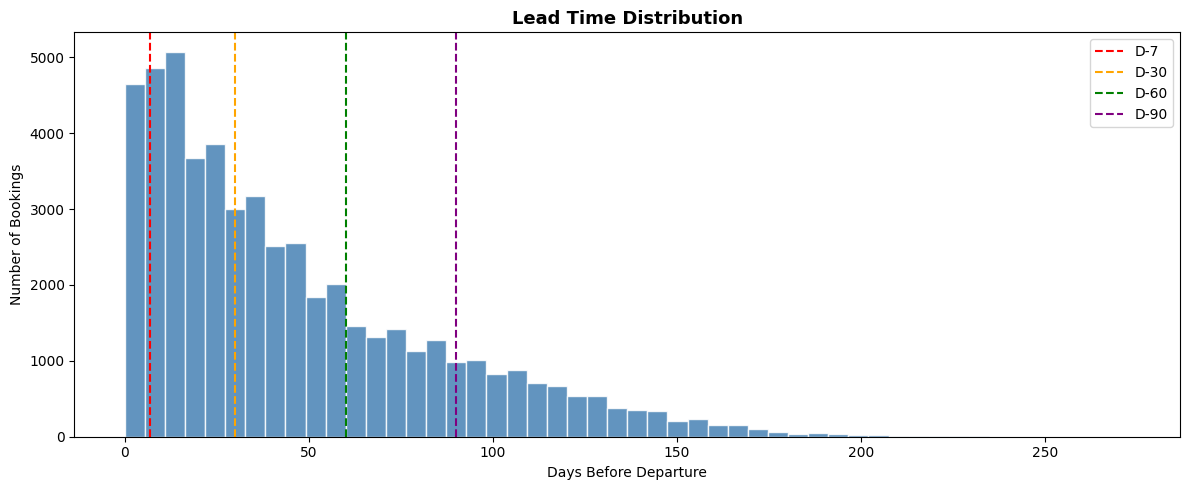

In [45]:
# Figure 1: Lead Time Distribution

# Step 1: Filter out negative lead times (bookings after departure)
lt_clean = df_claims[df_claims['LeadTimeDays'] >= 0]['LeadTimeDays']

# Step 2: Create the histogram
plt.figure(figsize=(12, 5))
plt.hist(lt_clean, bins=50, color='steelblue', edgecolor='white', alpha=0.85)

# Step 3: Add vertical lines for each booking window
plt.axvline(x=7,  color='red',    linestyle='--', label='D-7')
plt.axvline(x=30, color='orange', linestyle='--', label='D-30')
plt.axvline(x=60, color='green',  linestyle='--', label='D-60')
plt.axvline(x=90, color='purple', linestyle='--', label='D-90')

# Step 4: Add labels and title
plt.title('Lead Time Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Days Before Departure')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()

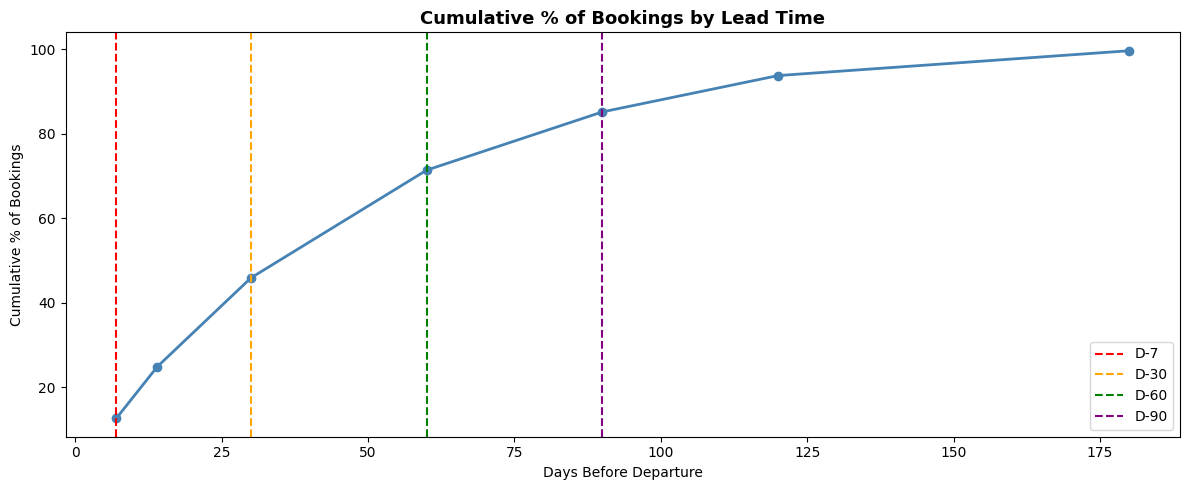

In [46]:
# Figure 2: Cumulative % of Bookings by Lead Time

# Step 1: Define the booking windows we want to check
windows = [7, 14, 30, 60, 90, 120, 180]

# Step 2: For each window, calculate what % of bookings happened by that day
cumulative = [
    len(lt_clean[lt_clean <= x]) / len(lt_clean) * 100
    for x in windows
]

# Step 3: Plot the cumulative curve
plt.figure(figsize=(12, 5))
plt.plot(windows, cumulative, marker='o', color='steelblue', linewidth=2)

# Step 4: Add vertical lines for booking windows
plt.axvline(x=7,  color='red',    linestyle='--', label='D-7')
plt.axvline(x=30, color='orange', linestyle='--', label='D-30')
plt.axvline(x=60, color='green',  linestyle='--', label='D-60')
plt.axvline(x=90, color='purple', linestyle='--', label='D-90')

# Step 5: Add labels and title
plt.title('Cumulative % of Bookings by Lead Time',
          fontsize=13, fontweight='bold')
plt.xlabel('Days Before Departure')
plt.ylabel('Cumulative % of Bookings')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
print('LEAD TIME STATISTICS')
for d in [7, 30, 60, 90, 120]:
    pct = round(len(lt_clean[lt_clean <= d]) / len(lt_clean) * 100, 1)
    print(f'Booked within D-{d:>3}: {pct}%')

LEAD TIME STATISTICS
Booked within D-  7: 12.7%
Booked within D- 30: 45.9%
Booked within D- 60: 71.4%
Booked within D- 90: 85.2%
Booked within D-120: 93.8%


#### 2. Booking Pace Over Time

Booking pace shows how many tour packages were booked per month
and week. This reveals demand trends and seasonal patterns.

In [56]:
# Convert all date columns from string to datetime
# errors='coerce' converts invalid values like \N to NaT (null date)
df_claims['ClaimCreatedDT_UTC'] = pd.to_datetime(df_claims['ClaimCreatedDT_UTC'], errors='coerce')
df_claims['DepartureDT']        = pd.to_datetime(df_claims['DepartureDT'],        errors='coerce')
df_claims['TourEndDT']          = pd.to_datetime(df_claims['TourEndDT'],           errors='coerce')
df_claims['ConfirmedDT_UTC']    = pd.to_datetime(df_claims['ConfirmedDT_UTC'],     errors='coerce')

print(df_claims[['ClaimCreatedDT_UTC', 'DepartureDT', 'ConfirmedDT_UTC']].dtypes)

# Check how many NaT values appeared
print('\nNaT values after conversion:')
print(f'ClaimCreatedDT_UTC: {df_claims["ClaimCreatedDT_UTC"].isna().sum()}')
print(f'DepartureDT:        {df_claims["DepartureDT"].isna().sum()}')
print(f'ConfirmedDT_UTC:    {df_claims["ConfirmedDT_UTC"].isna().sum()}')

ClaimCreatedDT_UTC    datetime64[ns]
DepartureDT           datetime64[ns]
ConfirmedDT_UTC       datetime64[ns]
dtype: object

NaT values after conversion:
ClaimCreatedDT_UTC: 0
DepartureDT:        0
ConfirmedDT_UTC:    2236


/tmp/ipykernel_698/1419616367.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active['BookingMonth'] = active['ClaimCreatedDT_UTC'].dt.to_period('M')


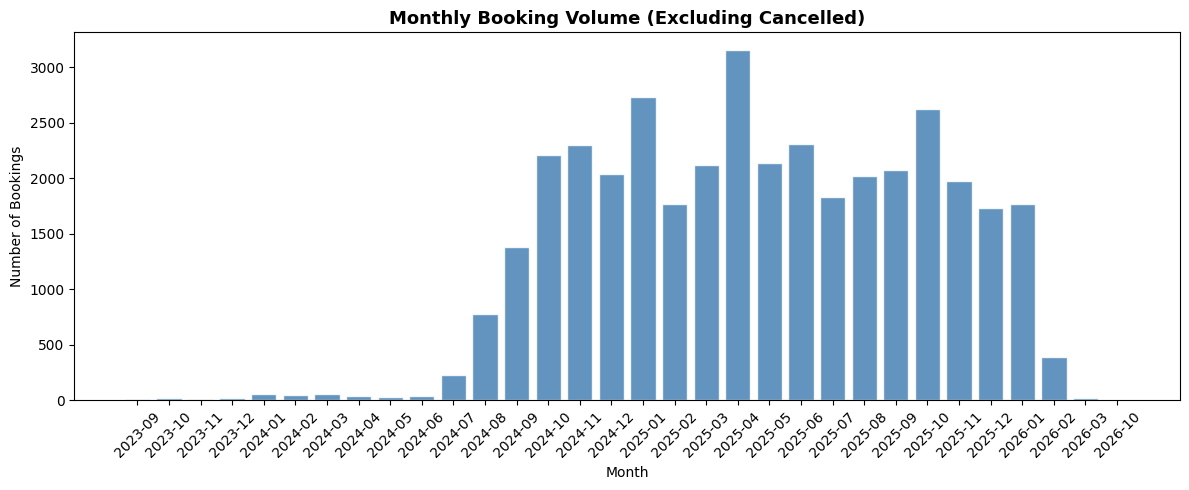

In [57]:
# Figure 3: Monthly Booking Volume (Excluding Cancelled)

# Step 1: Filter out cancelled bookings
active = df_claims[df_claims['IsCancelled'] == 0]

# Step 2: Extract the month from the booking date
active['BookingMonth'] = active['ClaimCreatedDT_UTC'].dt.to_period('M')

# Step 3: Count how many bookings happened in each month
monthly_active = active.groupby('BookingMonth').size().reset_index(name='Bookings')

# Step 4: Draw the bar chart per month
plt.figure(figsize=(12, 5))
plt.bar(monthly_active['BookingMonth'].astype(str), monthly_active['Bookings'],
        color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Monthly Booking Volume (Excluding Cancelled)',
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Seasonality Patterns

Seasonality analysis examines which months and days of the week
have the highest booking demand for Vietnam routes.

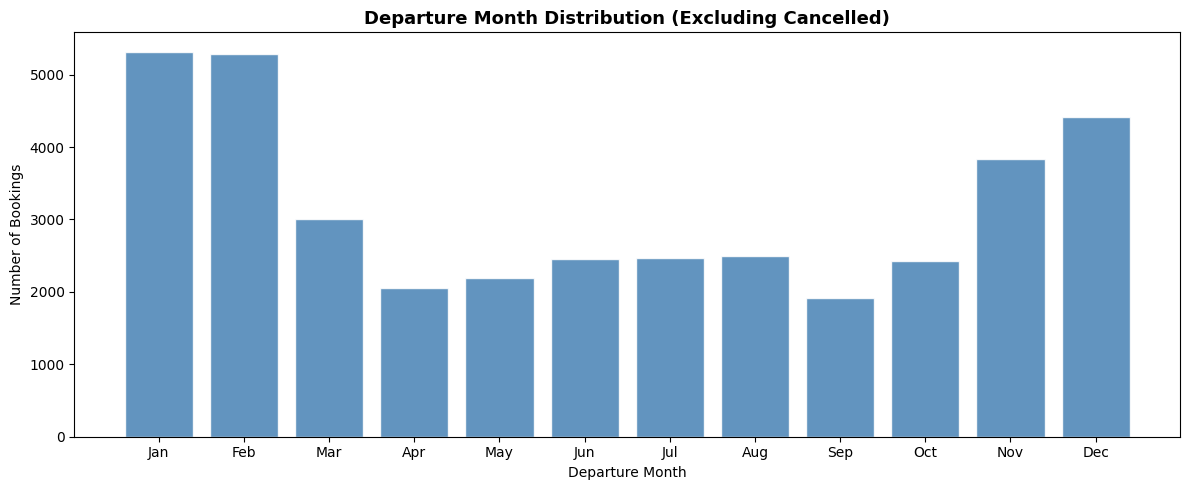

In [58]:
# Figure 4: Departure Month Distribution

# Step 1: Extract departure month
df_claims['DepartureMonth'] = df_claims['DepartureDT'].dt.month

# Step 2: Month names for readable format
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Step 3: Exclude cancelled bookings
# Cancelled = no demand
active = df_claims[df_claims['StatusName'] != 'Canceled']
monthly_dep = active.groupby('DepartureMonth').size()

# Step 4: Plot
plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_dep.values,
        color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Departure Month Distribution (Excluding Cancelled)',
          fontsize=13, fontweight='bold')
plt.xlabel('Departure Month')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

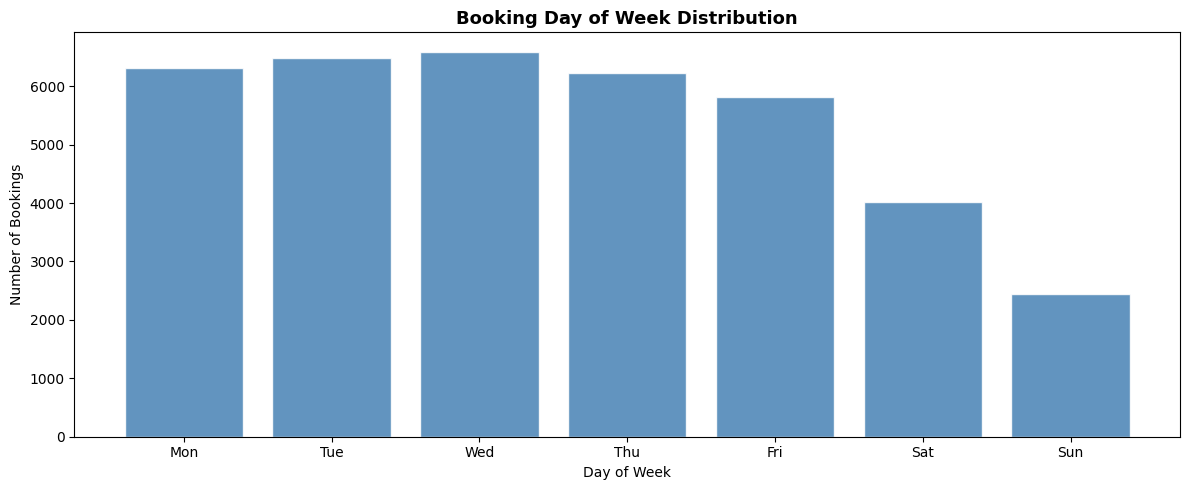

In [59]:
# Figure 5: Booking Day of Week

# Step 1: Extract day of week from booking creation date
# 0 = Monday, 6 = Sunday
df_claims['DayOfWeek'] = df_claims['ClaimCreatedDT_UTC'].dt.dayofweek

# Step 2: Day names
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# Step 3: Count bookings per day (excluding cancelled)
active = df_claims[df_claims['StatusName'] != 'Canceled']
daily_count = active.groupby('DayOfWeek').size()

# Step 4: Plot
plt.figure(figsize=(12, 5))
plt.bar(day_names, daily_count.values,
        color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Booking Day of Week Distribution',
          fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

### 4. Cancellation Pattern by Lead Time

This analysis examines whether cancellation rate changes depending
on how far in advance the booking was made. High cancellation rates
at certain lead times affect the reliability of demand signals.

/tmp/ipykernel_698/4107670777.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['StatusName'] == 'Canceled').sum() / len(x) * 100)


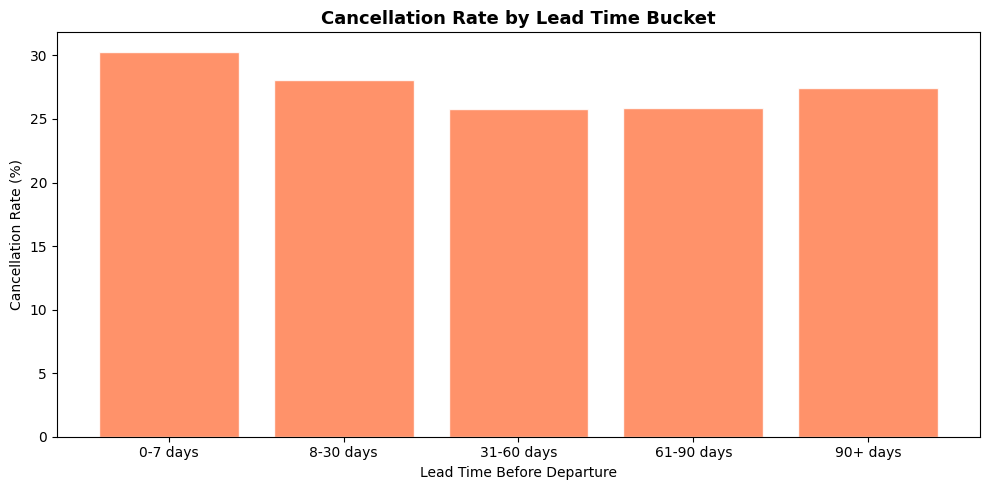

Cancellation Rate by Lead Time Bucket:
    0-7 days: 30.3%
   8-30 days: 28.1%
  31-60 days: 25.8%
  61-90 days: 25.9%
    90+ days: 27.4%


In [61]:
# Figure 6: Cancellation Rate by Lead Time Bucket

# Step 1: Remove negative lead times (data errors)
df_valid = df_claims[df_claims['LeadTimeDays'] >= 0].copy()

# Step 2: Create lead time buckets
# These match our booking windows D-7, D-30, D-60, D-90
def lead_time_bucket(days):
    if days <= 7:   return '0-7 days'
    elif days <= 30:  return '8-30 days'
    elif days <= 60:  return '31-60 days'
    elif days <= 90:  return '61-90 days'
    else:             return '90+ days'

df_valid['LeadTimeBucket'] = df_valid['LeadTimeDays'].apply(lead_time_bucket)

# Step 3: Calculate cancellation rate per bucket
# cancellation rate = cancelled / total bookings in that bucket
bucket_order = ['0-7 days', '8-30 days', '31-60 days', '61-90 days', '90+ days']

cancel_rate = (
    df_valid.groupby('LeadTimeBucket')
    .apply(lambda x: (x['StatusName'] == 'Canceled').sum() / len(x) * 100)
    .reindex(bucket_order)
    .round(1)
)

# Step 4: Plot
plt.figure(figsize=(10, 5))
plt.bar(cancel_rate.index, cancel_rate.values,
        color='coral', edgecolor='white', alpha=0.85)
plt.title('Cancellation Rate by Lead Time Bucket',
          fontsize=13, fontweight='bold')
plt.xlabel('Lead Time Before Departure')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

# Step 5: Print the values
print('Cancellation Rate by Lead Time Bucket:')
for bucket, rate in cancel_rate.items():
    print(f'{bucket:>12}: {rate}%')

### 5. Price Distribution

Price distribution analysis examines the spread of flight and hotel
costs across all bookings. This helps identify outliers, understand
pricing segments and prepare the Price Ratio feature for modelling.

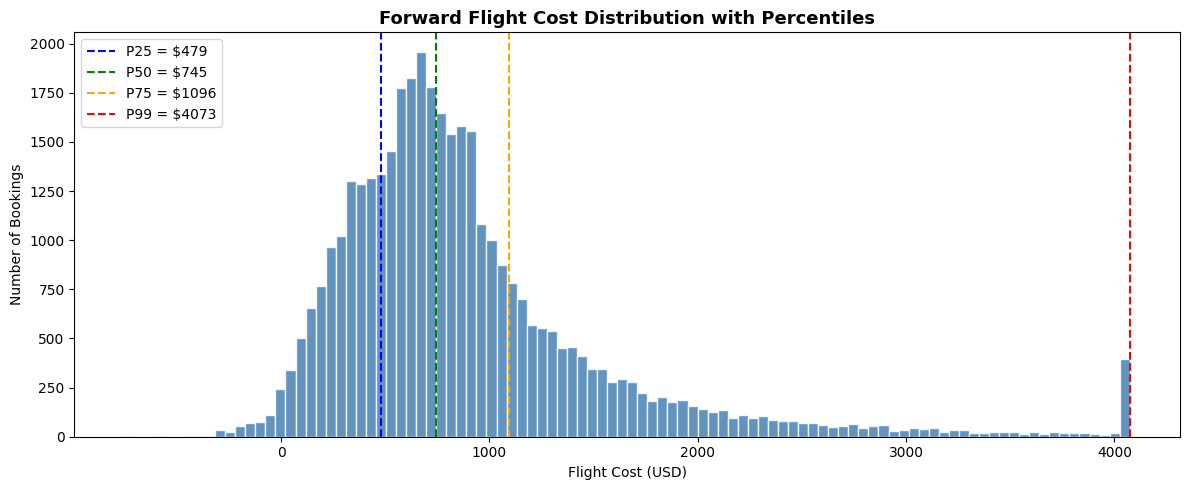

FLIGHT COST PERCENTILES (USD)
P 1: $  -35.36
P 5: $  150.60
P25: $  479.28
P50: $  745.24
P75: $ 1095.50
P90: $ 1692.31
P95: $ 2262.00
P99: $ 4073.31

ANOMALY CHECK
Negative flight costs: 500
Zero flight costs:     4


In [62]:
# Figure 7: Flight Cost Distribution

# Step 1: Calculate key percentiles
p25 = active['FlightCost_Fwd'].quantile(0.25)
p50 = active['FlightCost_Fwd'].quantile(0.50)
p75 = active['FlightCost_Fwd'].quantile(0.75)
p99 = active['FlightCost_Fwd'].quantile(0.99)

# Step 2: Plot histogram
plt.figure(figsize=(12, 5))
plt.hist(active['FlightCost_Fwd'].clip(upper=p99),
         bins=100,              # 100 bins = fine-grained view
         color='steelblue',
         edgecolor='white',
         alpha=0.85)

# Step 3: Add vertical lines for each percentile
plt.axvline(x=p25, color='blue',   linestyle='--',
            linewidth=1.5, label=f'P25 = ${p25:.0f}')
plt.axvline(x=p50, color='green',  linestyle='--',
            linewidth=1.5, label=f'P50 = ${p50:.0f}')
plt.axvline(x=p75, color='orange', linestyle='--',
            linewidth=1.5, label=f'P75 = ${p75:.0f}')
plt.axvline(x=p99, color='red',    linestyle='--',
            linewidth=1.5, label=f'P99 = ${p99:.0f}')

# Step 4: Add labels and title
plt.title('Forward Flight Cost Distribution with Percentiles',
          fontsize=13, fontweight='bold')
plt.xlabel('Flight Cost (USD)')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Print all percentiles as a table
print('FLIGHT COST PERCENTILES (USD)')
for p in [1, 5, 25, 50, 75, 90, 95, 99]:
    val = active['FlightCost_Fwd'].quantile(p/100)
    print(f'P{p:>2}: ${val:>8.2f}')

# Step 6: Count anomalies
print('\nANOMALY CHECK')
print(f'Negative flight costs: {(active["FlightCost_Fwd"] < 0).sum()}')
print(f'Zero flight costs:     {(active["FlightCost_Fwd"] == 0).sum()}')

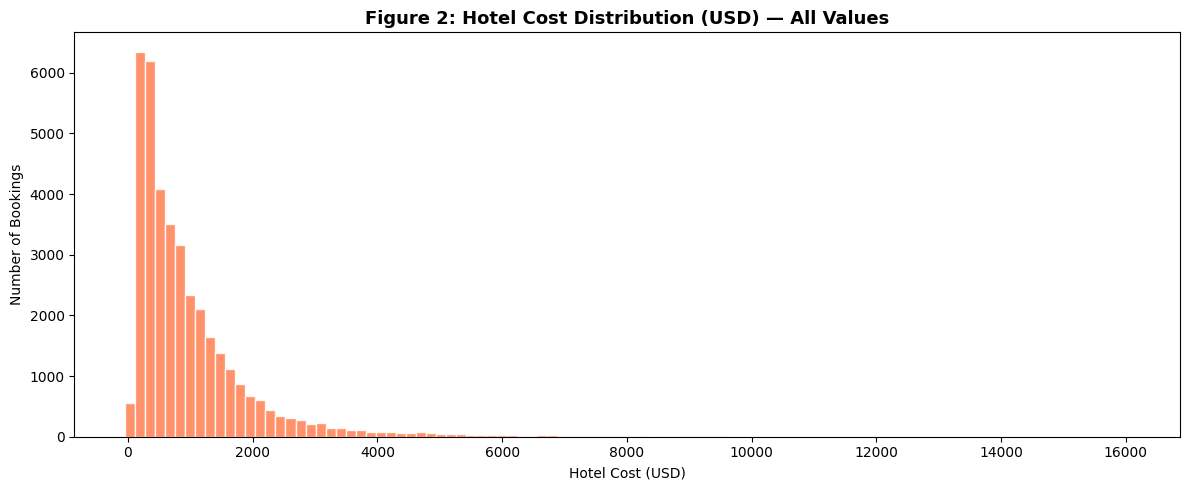

HOTEL COST STATISTICS (USD)
────────────────────────────────────────
count    37884.00
mean       986.47
std       1055.62
min        -52.36
25%        326.28
50%        668.50
75%       1249.45
max      16063.42
Name: HotelCost, dtype: float64

Zero hotel cost: 150
Negative hotel cost: 24


In [63]:
# Figure 8: Hotel Cost Distribution

# Note: We keep ALL values, including negative and zero costs
# Negative costs or Zero costs = could be infotour, complimentary or other special claims
# We need to understand these values — not remove them

# Step 1: Exclude only cancelled bookings
active = df_claims[df_claims['StatusName'] != 'Canceled'].copy()

# Step 2: Plot histogram with ALL hotel cost values
plt.figure(figsize=(12, 5))
plt.hist(active['HotelCost'], bins=100,
         color='coral', edgecolor='white', alpha=0.85)
plt.title('Figure 2: Hotel Cost Distribution (USD) — All Values',
          fontsize=13, fontweight='bold')
plt.xlabel('Hotel Cost (USD)')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

# Step 3: Print key statistics
print('HOTEL COST STATISTICS (USD)')
print('─' * 40)
print(active['HotelCost'].describe().round(2))

# Step 4: Investigate zero and negative values
print('\nZero hotel cost:',
      (active['HotelCost'] == 0).sum())
print('Negative hotel cost:',
      (active['HotelCost'] < 0).sum())

### 2) EDA for df_flights

1. Load Factor Distribution
2. Load Factor by Route
3. Load Factor by Airline
4. Load Factor Over Time
5. Load Factor by Demand Category

### 3) Joint Analysis — Key Relationships

1. FreightID Match Rate
2. Lead Time vs Load Factor
3. Booking Pace vs Load Factor

### 4) Outlier & Data Quality Analysis

1. Negative Lead Times
2. Zero and 100% Load Factor Flights